# 7 优化算法

优化算法使我们能够更新模型参数，并使损失函数的值最小化。优化算法对深度学习非常重要。一方面，训练复杂的深度学习模型非常耗时，优化算法的性能直接影响模型的训练效率。另一方面，了解不同的优化算法的原则及其超参数的作用有助于针对性的方式调整查参数，一高深度学习的性能。

## 7.1 优化和深度学习

对于深度学习问题，通常会先定义损失函数。一旦有了损失函数（目标函数），可以使用优化算法来尝试最小化损失。传统惯例，大多数优化算法都关注的是最小化。如果我们需要最大化目标，只需在目标函数前加负号即可。

### 优化的目标

本质上，优化和深度学习的目标是根本不同的。前者主要关注的是最小化目标函数（减少训练误差），后者则关注在给定有限数据量的情况下寻找合适的模型（减少泛化误差），所以需要注意过拟合。

为了说明上述两个不同的目标，引入概念风险和经验风险。经验风险是训练集的平均损失，风险是整个数据集的预期损失。定义两个函数，风险函数f和经验风险函数g

In [ ]:
import numpy as np
import torch
import sys 
sys.path.append('/home/kazundo/WorkSpace/Methods/bioinfo-dl-tutorial/src/utils')

from Plot import CurvePlot, GradientDescentPlot


def f(x):
    return x * torch.cos(np.pi * x)

def g(x):
    return f(x) + 0.2 * torch.cos(5* np.pi * x)

x = torch.arange(0.5, 1.5, 0.01)
CurvePlot(x, f(x), g(x), ['min of risk', 'min of empirical risk']) 

### 深度学习中的优化挑战

深度学习中，大多数目标函数都很复杂，没有解析解。相反，必须使用数值优化算法。

深度学习优化中存在许多挑战，如局部最小值，鞍点和梯度消失

#### 局部最小值

对于任何目标函数$f(x)$，如果x处对应的f(x)值小于在x附近任意其他点的f(x)值，那么f(x)可能是局部最小值。如果f(x)在x处的值是整个域中目标函数的最小值，那么f(x)是全局最小值。

深度学习模型的目标函数通常具有许多局部最优解。当优化问题的数值解决局部最优时，目标函数解的梯度接近或变为0，最终迭代获得的数值解可能仅使目标函数局部最优，而不是全局最优。只有一定程度的噪声可能会使得参数跳出局部最优值。即小批量随机梯度下降的有利特征之一，这种情况下小批量的自然变化能够将参数从局部极小值中跳出

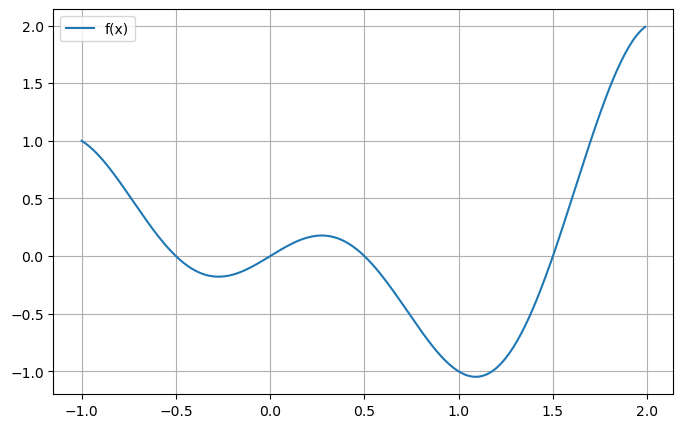

In [2]:
# 给定函数f(x) = x \cdot \ cos(\pi x)\  -1.0\le x \le 1.0

x = torch.arange(-1, 2, 0.01)
CurvePlot(x, f(x), None, ['f(x)'])

#### 鞍点
鞍点（saddle point）是梯度消失的另一个原因，是指函数的所有梯度都消失但不是全局最小值也不是局部最小值的位置。


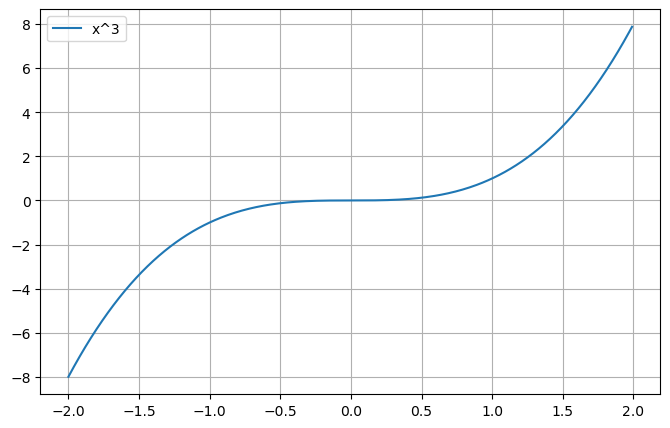

In [3]:
# 如f(x) = x ** 3。它的一阶导和二阶导在x=0时可能消失，这时优化可能停止。

x = torch.arange(-2.0, 2.0, 0.01)
CurvePlot(x, x ** 3, None, ['x^3'])

/home/kazundo/miniconda3/envs/Bio/lib/python3.13/site-packages/torch/functional.py:534: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /home/conda/feedstock_root/build_artifacts/libtorch_1735184004493/work/aten/src/ATen/native/TensorShape.cpp:3595.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


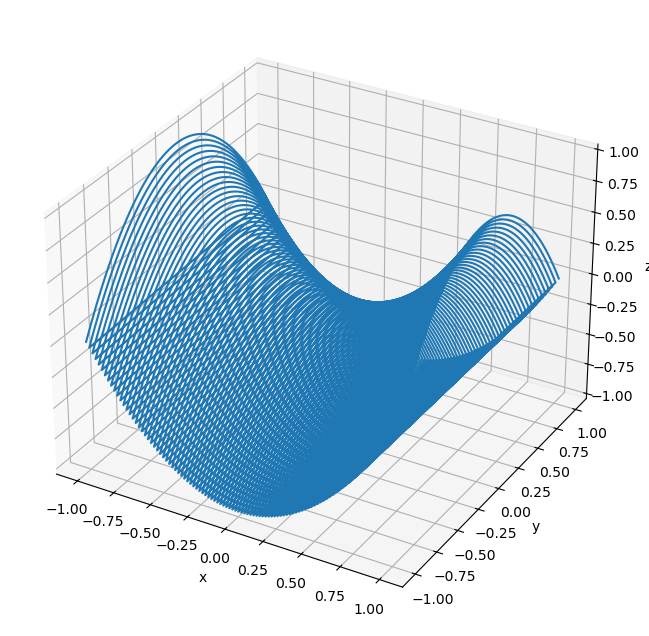

In [4]:
# 较高维度的鞍点更加隐蔽。如f(x,y) = x^2 - y^2。其鞍点为(0,0)，这是关于y的最大值，也是关于x的最小值，看上去像个马鞍。

x, y = torch.meshgrid(
    torch.linspace(-1,1,101), torch.linspace(-1,1,101))

z = x**2 - y**2

import matplotlib.pyplot as plt
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

ax.plot(x, y, z)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
plt.show()

假设函数的输入时k维向量，因此其Hessian矩阵（也称为黑塞矩阵）将有k个特征值，函数的解可能在局部最小值，局部最大值或函数梯度为0处的鞍点：
- 当函数在0梯度位置处的Hessian矩阵的特征值全部为正值时，有该函数的局部最小值
- 当函数在0梯度位置处的Hessian矩阵的特征值全部为负值时，有该函数的局部最大值
- 当函数在0梯度位置处的Hessian矩阵的特征值为正值或负值时，有该函数的一个鞍点

对于高维度问题，至少部分特征值为负的可能性相当高，使得鞍点比局部极小值点更易出现。

凸函数时Hessian函数的特征值永远不为负值的函数，但大多数深度学习问题不属于这一类。

#### 梯度消失

可能遇到的最隐蔽问题是梯度消失。某些激活函数及其衍生函数会恰好从0或接近梯度开始，优化会停滞很长一段时间。

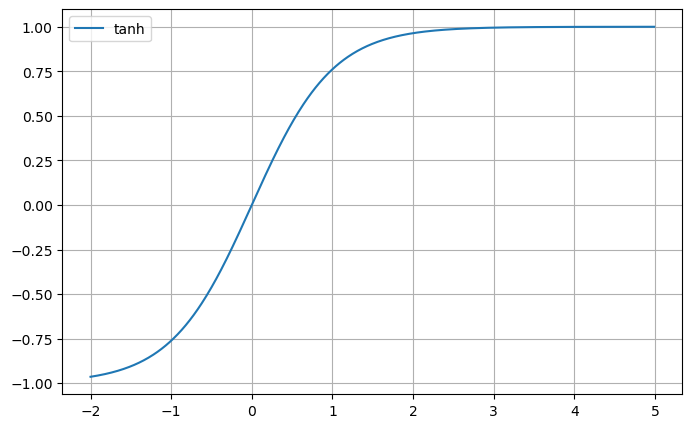

In [5]:
x = torch.arange(-2, 5, 0.01)
CurvePlot(x, torch.tanh(x), None, ['tanh'])

深度学习的优化充满挑战，然而有一系列强大的算法表现良好，即使对于初学者也容易使用。此外，也没必要找到最优解，局部最优解或其近似解仍然非常有用

## 7.2 凸性

凸性（convexity）在算法设计中起到至关重要的作用，主要是优于在这种情况下对算法进行分析和测试较为容易。若算法在凸性设定条件下效果很差，其他条件下很难看到好结果。即使深度学习中的优化问题通常非凸，在局部极小值附近表现出凸性。

### 定义

#### 凸集

凸集（convex set）是凸性的基础。对于任何$a,b\in\cal X$，连接$a,b$的线段也位于$\cal X$中，则向量空间中的一个集合$\cal X$是凸（convex）的，即对于所有的$\lambda\in[0,1]$
$$
\lambda a+(1-\lambda)b\in\mathcal X\ 当a,b\in\cal X 
$$

假设$\cal X、Y$是凸集，那么$\cal X\cap Y$也是凸集，但凸集的并集不一定是凸的

#### 凸函数

凸函数（convex function）：给定一个凸集$\cal X$，对于所有的$x,x'\in\cal X$，$\lambda\in[0,1]$，有
$$
\lambda f(x)+(1-\lambda)f(x')\ge f(\lambda x+(1-\lambda)x')
$$
则称$f:\mathcal X\to\mathbb R$是凸的


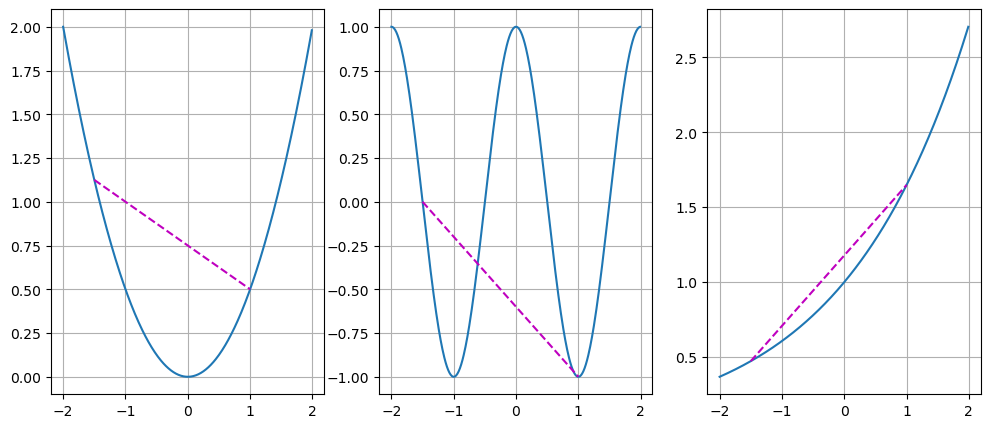

In [6]:
x, segment = torch.arange(-2, 2, 0.01), torch.tensor([-1.5, 1])

f = lambda x: 0.5 * x ** 2 #凸函数
g = lambda x: torch.cos(np.pi * x) # 非凸函数
h = lambda x: torch.exp(0.5 * x) # 凸函数

fig, axes = plt.subplots(1, 3, sharex=True, figsize=(12, 5))
axes[0].plot(x, f(x))
axes[0].plot(segment, f(segment), 'm--')
axes[0].grid()
axes[1].plot(x, g(x))
axes[1].plot(segment, g(segment), 'm--')
axes[1].grid()
axes[2].plot(x, h(x))
axes[2].plot(segment, h(segment), 'm--')
axes[2].grid()

#### 詹森不等式

给定一个凸函数$f$，最有用的数学工具之一就是詹森不等式（Jensen's inequality）。
$$
\sum_i\alpha_if(x_i)\ge f\bigg(\sum_i\alpha_i x_i\bigg)\mathrm{and}\ \mathbb E_x[f(X)]\ge f(\mathbb E_x[X])
$$
其中$\alpha_i$满足$\sum_i\alpha_i=1$的非负实数，X是随机变量。即凸函数的期望不小于期望的凸函数。

### 性质
#### 局部极小值是全局极小值

凸函数的局部极小值是全局极小值。

#### 凸函数的下水平集是凸的

给定一个定义在凸集$\cal X$上的凸函数f，其任意一个下水平集（below sets）
$$
\mathcal S_b:=\{x|x\in\mathcal X\ \mathrm{and}\ f(x)\le b\}
$$
是凸的。

#### 凸性和二阶导数

对于任意二次可微多维函数$f:\mathbb R^n\to\mathbb R$，它是凸的当且仅当它的Hessian $\nabla^2f\ge 0$



### 约束
凸优化的一个特性是能够有效地处理约束（constraints）。能够解决以下形式的约束优化（constrained optimization）问题：
$$
\min_x f(\mathbf x)
subject to c_i(\mathbf x)\le 0\ \forall i\in\{1,...,N\}
$$
其中，f是目标函数，$c_i$是约束函数

#### 拉格朗日函数
拉格朗日函数L的推导，优化问题表示为：
$$
L(\mathbf x,\alpha_1,...,\alpha_n)=f(\mathbf x)+\sum_{i=1}^n\alpha_ic_i(\mathbf x)\ 其中，\alpha_i\ge 0
$$
其中，变量$\alpha_i$是拉格朗日乘数（Lagrange multipliers）。在这个问题中，想要使得L相对于$\alpha_i$最大化（maximize），相对于$\mathbf x$最小化（minimize）。

#### 惩罚

一种至少近似地满足约束优化问题的方法是采用拉格朗日函数L。通常，添加惩罚是确保满足约束的一种好方法。

#### 投影

满足约束条件的另一种策略是投影（projections），凸集$\cal X$上的投影被定义为
$$
Proj_{\cal X}(x) = \min_{x;\in\cal X}||\mathbf{x - x'}||
$$
表示$\cal X$中离$\mathbf X$最近的点

## 7.3 梯度下降

### 一维梯度下降



epoch:0	 x:6.00000
epoch:1	 x:3.60000
epoch:2	 x:2.16000
epoch:3	 x:1.29600
epoch:4	 x:0.77760
epoch:5	 x:0.46656
epoch:6	 x:0.27994
epoch:7	 x:0.16796
epoch:8	 x:0.10078
epoch:9	 x:0.06047


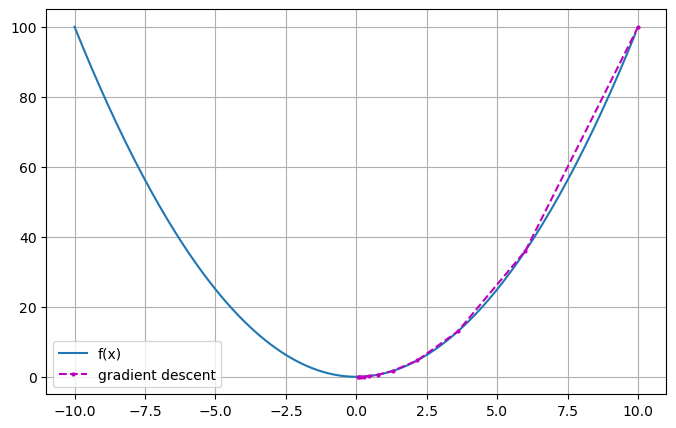

In [89]:
def f(x): # 目标函数
    return x ** 2

def f_grad(x): # 目标函数的梯度（导数）
    return 2 * x

def gd(eta, f_grad, x0):
    x = torch.tensor(x0, dtype=float)
    results = [x.item()]
    for epoch in range(10):
        x -= eta * f_grad(x)
        print(f'epoch:{epoch}\t x:{x.item():.5f}')
        results.append(x.item())
    return torch.tensor(results)
x = torch.arange(-10, 10, 0.1)
x_ = gd(0.2, f_grad, 10)

GradientDescentPlot(x, x_, f)

#### 学习率

学习率（learning rate）决定目标函数能否收敛到局部最小值，以及何时收敛到最小值。

epoch:0	 x:9.00000
epoch:1	 x:8.10000
epoch:2	 x:7.29000
epoch:3	 x:6.56100
epoch:4	 x:5.90490
epoch:5	 x:5.31441
epoch:6	 x:4.78297
epoch:7	 x:4.30467
epoch:8	 x:3.87420
epoch:9	 x:3.48678


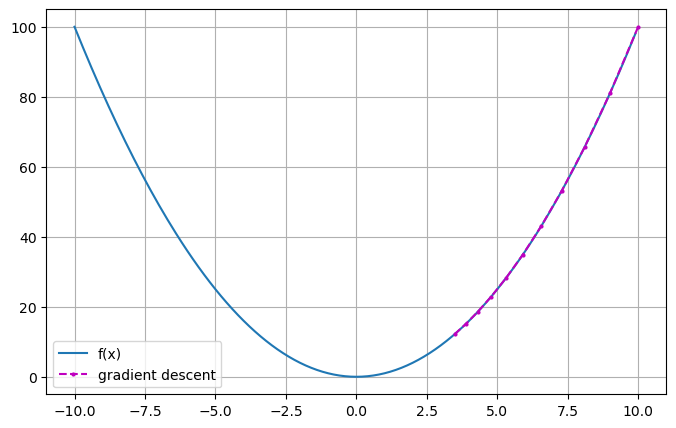

In [91]:
# 如果学习率设置太小，将导致x的更新缓慢，需要更多的迭代
x_ = gd(0.05, f_grad, 10)
GradientDescentPlot(x, x_, f)

epoch:0	 x:-5.00000
epoch:1	 x:2.50000
epoch:2	 x:-1.25000
epoch:3	 x:0.62500
epoch:4	 x:-0.31250
epoch:5	 x:0.15625
epoch:6	 x:-0.07812
epoch:7	 x:0.03906
epoch:8	 x:-0.01953
epoch:9	 x:0.00977


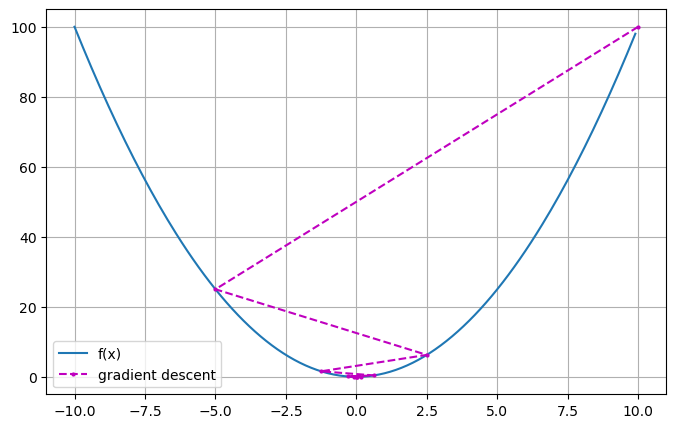

In [92]:
# 若学习率过高，则x的迭代不能保证降低f(x)的值 
x_ = gd(0.75, f_grad, 10)
GradientDescentPlot(x, x_, f)

epoch:0	 x:0.57522
epoch:1	 x:-1.20659
epoch:2	 x:-2.27960
epoch:3	 x:-1.34342
epoch:4	 x:-2.20677
epoch:5	 x:-1.42579
epoch:6	 x:-2.15463
epoch:7	 x:-1.48388
epoch:8	 x:-2.11435
epoch:9	 x:-1.52817


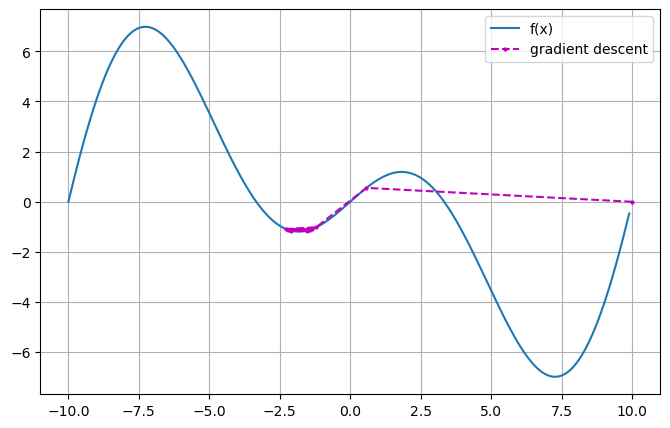

In [93]:
c = torch.tensor(np.pi * 0.15)

def f(x): # 目标函数
    return x * torch.cos(c * x)

def f_grad(x): # 目标函数的梯度
    return torch.cos(c * x) - c * x * torch.sin(c * x)

x_ = gd(2, f_grad, 10)

GradientDescentPlot(x, x_, f)

### 多元梯度下降

考虑$\mathbf x=[x_1,x_2,...,x_d]^\top$的情况。即目标函数$f:\mathbb R^d\to\mathbb R$将向量映射为标量。其梯度维一个由d个偏导数组成的向量：
$$
\nabla f(x)=\bigg[\frac{\partial f(\mathbf x)}{\partial x_1}, \frac{\partial f(\mathbf x)}{\partial x_2}, ..., \frac{\partial f(\mathbf x)}{\partial x_d} \bigg]^\top
$$

梯度中的每个偏导数元素$\partial f(\mathbf x)/\partial x_i$代表了当输入$x_i$时在$\mathbf x$处的变化率，最陡下降的方向由负梯度$-\nabla f(\mathbf x)$得出。选择合适的学习率$\eta\gt 0$来生成典型的梯度下降算法：
$$
\mathbf x\leftarrow\mathbf x-\eta\nabla f(\mathbf x)
$$



In [118]:
# f(x)=x_1^2 + 2x_2^2为例

def f(x1, x2):
    return x1**2 + 2*x2**2

def f_grad(x1, x2):
    return (2*x1, 4*x2)

def gd(eta, f_grad, x1, x2):
    results = [[x1, x2]]

    for epoch in range(50):
        s1, s2 = f_grad(x1, x2)
        x1 = x1 - eta * s1
        x2 = x2  - eta *  s2
        results.append([x1, x2])
    print(f'epoch:{epoch}\tx1:{x1:.5f},x2{x2:.5f}')
    return torch.tensor(results, dtype=float)

epoch:49	x1:-0.00007,x2-0.00000


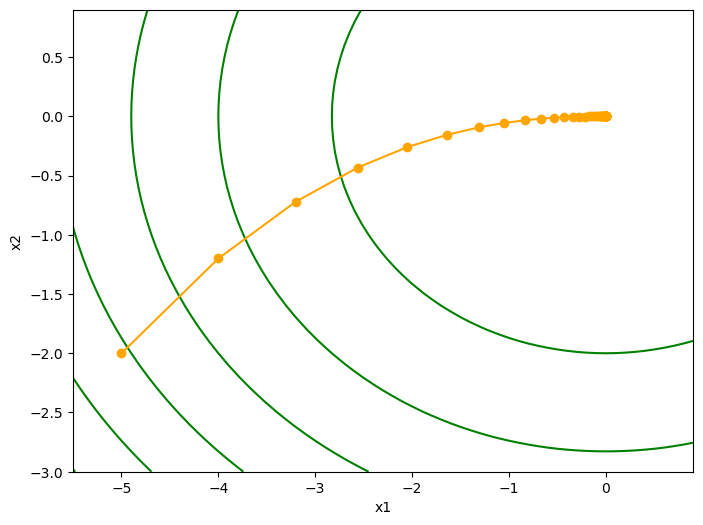

In [119]:
results = gd(0.1, f_grad, -5, -2)

def GradientPlot_2d(x1_range, x2_range, f, results):
    
    plt.figure(figsize=(8,6))
    x1, x2 = torch.meshgrid(torch.arange(x1_range[0], x1_range[1], 0.1), 
                            torch.arange(x2_range[0], x2_range[1], 0.1), indexing='ij' )
    plt.contour(x1, x2, f(x1, x2), colors='green')
    plt.plot(*zip(*results), '-o', color='orange') # 内层*号将列表打开，作为输入参数，zip函数按列重组，外层*号打开为两列输入
    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.show()

GradientPlot_2d([-5.5, 1.0], [-3.0, 1.0], f, results)

### 自适应方法

选择恰到好处的学习率η非常棘手。太小会收敛缓慢，太大会震荡甚至发散。

#### 牛顿法

一些函数$f:\mathbb R\to\mathbb R$的泰勒展开为：
$$
f(\mathbb x+\mathbb \epsilon)=f(\mathbb x)+\epsilon^\top\nabla f(\mathbf x)+\frac{1}{2}\epsilon^\top\nabla^2f(\mathbf x)\epsilon +\mathcal O(||\epsilon||^3)
$$
将$\mathbf H\overset {def} = \nabla^2f(x)$定义为Hessian。f的最小值满足f(x)=0，得到
$$
\nabla f(\mathbf x)+\mathbf{H\epsilon}\quad因此\epsilon=-\mathbf{H^{-1}}\nabla f(\mathbf x) 
$$

梯度更新为
$$
\mathbf x\leftarrow\mathbf x-\eta\nabla f(\mathbf x) \mathbf H^{-1}
$$

当$\mathbf H$较大，即曲率较大（陡峭）时采用谨慎的步长，而在曲率较小（平坦）采用较大的学习率

epoch:0	 x:8.00018
epoch:1	 x:6.00152
epoch:2	 x:4.01140
epoch:3	 x:2.08254
epoch:4	 x:0.52576
epoch:5	 x:0.01179
epoch:6	 x:0.00000
epoch:7	 x:0.00000
epoch:8	 x:0.00000
epoch:9	 x:0.00000


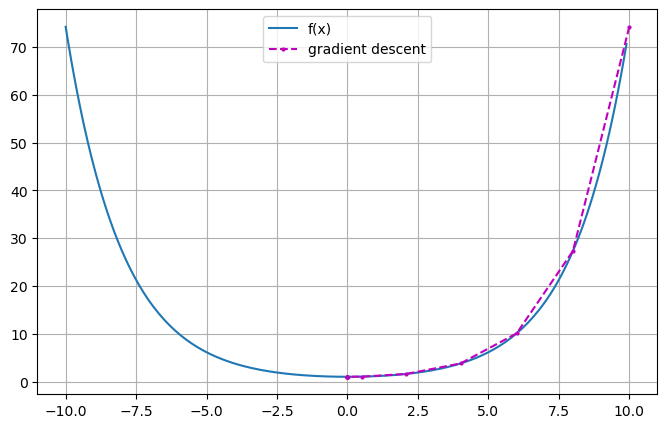

In [95]:
# 以双曲余弦函数为例
c = torch.tensor(0.5)

def f(x): # 目标函数
    return torch.cosh(c * x)

def f_grad(x): # 目标函数的梯度
    return c * torch.sinh(c * x)

def f_hess(x): # 目标函数的Hessian
    return c ** 2 * torch.cosh(c * x)

def newton(eta, f_grad, f_hess, x0):
    x = torch.tensor(x0, dtype=float)
    results = [x.item()]
    for epoch in range(10):
        x -= eta * f_grad(x) / f_hess(x)
        print(f'epoch:{epoch}\t x:{x.item():.5f}')
        results.append(x.item())
    return torch.tensor(results)

x_ = newton(1, f_grad, f_hess, 10)
GradientDescentPlot(x, x_, f)

epoch:0	 x:5.00000
epoch:1	 x:24.99510
epoch:2	 x:27.78266
epoch:3	 x:26.80017
epoch:4	 x:26.83418
epoch:5	 x:26.83413
epoch:6	 x:26.83413
epoch:7	 x:26.83413
epoch:8	 x:26.83413
epoch:9	 x:26.83413


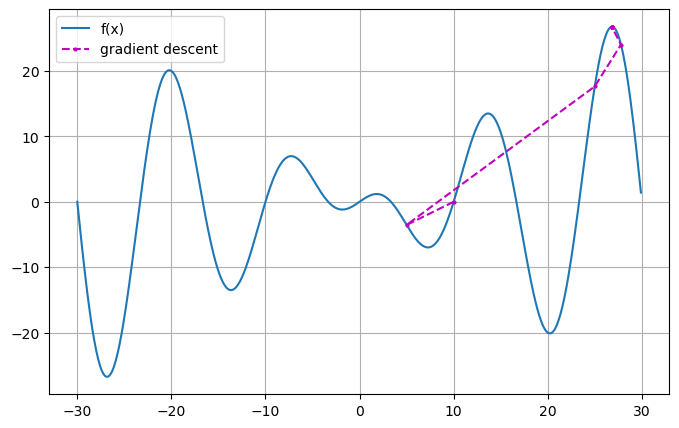

In [99]:
# 在一个非凸函数，当二阶导数为负时，f的值可能增加

c = torch.tensor(0.15 * np.pi)

def f(x): # 目标函数
    return x * torch.cos(c * x)

def f_grad(x): # 目标函数的梯度
    return torch.cos(c * x) - c * x * torch.sin(c * x) 

def f_hess(x): # 目标函数的Hessian
    return - 2 * c * torch.sin(c * x) - x * c ** 2 * torch.cos(c * x)
x = torch.arange(-30, 30, 0.1)
x_ = newton(1, f_grad, f_hess, 10)
GradientDescentPlot(x, x_, f)

epoch:0	 x:7.50000
epoch:1	 x:7.38716
epoch:2	 x:7.32900
epoch:3	 x:7.29939
epoch:4	 x:7.28444
epoch:5	 x:7.27693
epoch:6	 x:7.27316
epoch:7	 x:7.27128
epoch:8	 x:7.27033
epoch:9	 x:7.26986


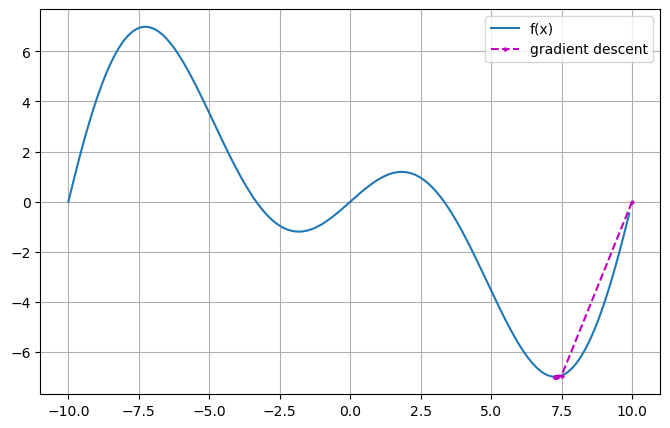

In [101]:
x = torch.arange(-10, 10, 0.1)
x_ = newton(0.5, f_grad, f_hess, 10)
GradientDescentPlot(x, x_, f)

#### 收敛性分析

收敛的速度为$|d^{(k+1)}|\le\alpha |d^{(k)}|$，称为恒定收敛速度。

#### 预处理

计算和存储完整的Hessian代价昂贵，一种改善方法是“预处理”，即只计算“对角线”，更新为：
$$
\mathbf x\leftarrow \mathbf x\to -\eta\mathrm{diag}(\mathbf H)^{-1}\nabla f(\mathbf x)
$$

#### 梯度下降和线搜索

梯度下降的一个问题可能会超过目标或进展不足，解决这一问题的方法是使用线搜索和梯度下降。即先使用$\nabla f(\mathbf x)$给出方向，然后进行二分搜索，确定哪个学习率$\eta$使得$f(\mathbf x-\eta\nabla f(\mathbf x))$取得最小值。但是对于深度学习而言代价昂贵。


## 7.4 随机梯度下降

随机梯度下降（stomatic gradient descent）。

#### 随机梯度更新

深度学习中，目标函数通常是训练数据中每个样本的损失函数的平均值。给定n个样本的训练数据集，假设$f_i(\mathbb x)$是关于索引i的训练样本的损失函数，其中$\mathbf x$是参数向量。得到目标函数
$$
f(\mathbf x)=\frac1m\sum_{i=1}f_i(\mathbf x)
$$
目标函数的梯度计算为
$$
\nabla f(\mathbf x)=\frac1n\sum_{i=1}^n\nabla f_i(\mathbf x)
$$
代价为$\mathcal O(n)$，随n线性增长。

随机梯度下降（SGD）对数据样本随机均匀采样一个索引$i\in\{1,...,n\}$，并计算梯度$\nabla f_i(\mathbb x)$以更新$\mathbb x$:
$$
\mathbb x\leftarrow -\eta\nabla f_i(\mathbb x)
$$

epoch:49	x1:0.05000,x2-0.01599


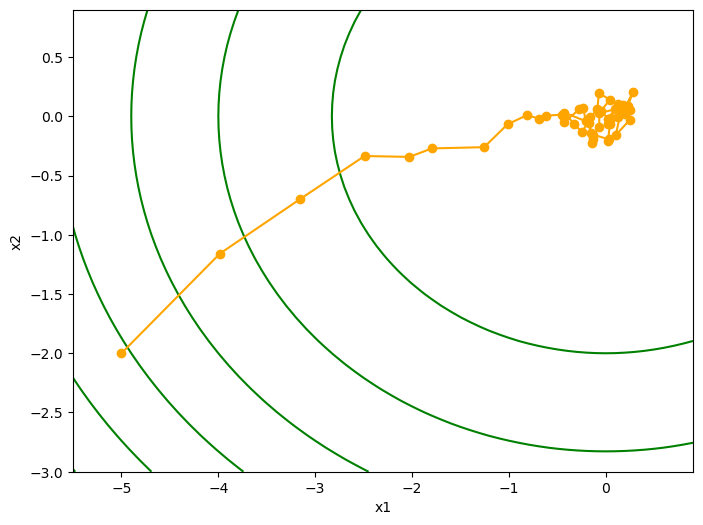

In [ ]:
# 将他与梯度下降进行比较，方法是向梯度添加均值为0、方差为1的随机噪声，模拟随机梯度

def f(x1, x2):
    return x1 ** 2 + 2 * x2 ** 2

def f_grad(x1, x2):
    return 2 * x1, 4 * x2

def sgd(eta, f_grad, x1, x2):
    results = [[x1, x2]]

    for epoch in range(50):
        g1, g2 = f_grad(x1, x2)
        g1 += torch.normal(0, 1, (1,)).item()
        g2 += torch.normal(0, 1, (1,)).item()
        x1 = x1 - eta * g1
        x2 = x2 - eta * g2
        results.append([x1, x2])
    print(f'epoch:{epoch}\tx1:{x1:.5f},x2:{x2:.5f}')
    return torch.tensor(results, dtype=float)

results = sgd(0.1, f_grad, -5, -2)
GradientPlot_2d([-5.5, 1.0], [-3.0, 1.0], f, results)

随机梯度下降中变量的轨迹比梯度下降中观察到的轨迹嘈杂的多，这是由于梯度的随机性质。解决这些相互冲突的目标的唯一方法就是在优化过程中动态降低学习率。

### 动态学习率

用与时间相关的学习率$\eta(t)$取代$\eta$增加了控制优化算法收敛的复杂性。基本策略
$$
\begin{aligned}
\eta(t) &= \eta_i \ \mathrm{if}\ t_i\le t\le t_{i+1}\quad 分段常数 \\
\eta(t) &= \eta_0\cdot e^{-\lambda t} \quad 指数衰减 \\
\eta(t) &= \eta_0\cdot (\beta t+1)^{-\alpha}\quad 多项式衰减
\end{aligned}
$$

epoch:49	x1:-0.37439,x2-0.06278


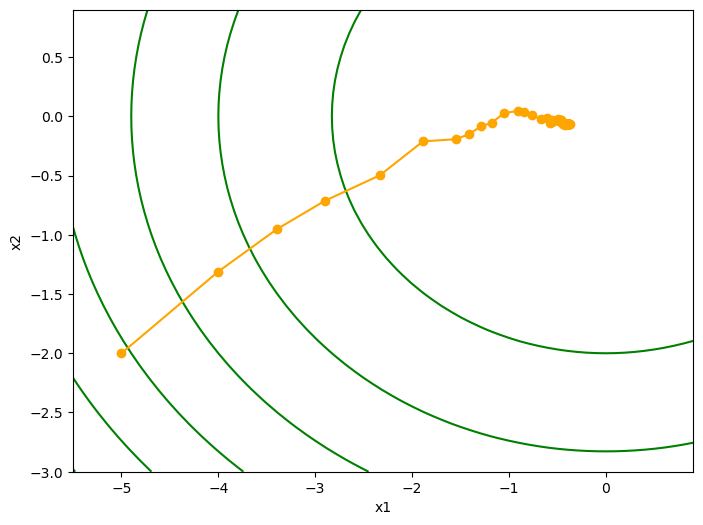

In [ ]:
# 指数衰减, 参数的方差大大减少，但是是以未能收敛到最优解为代价

def sgd(eta, f_grad, x1, x2):
    results = [[x1, x2]]
    eta = 0.1 * torch.exp(torch.arange(50) * -0.1)
    for epoch in range(50):
        g1, g2 = f_grad(x1, x2)
        g1 += torch.normal(0, 1, (1,)).item()
        g2 += torch.normal(0, 1, (1,)).item()
        x1 = x1 - eta[epoch] * g1
        x2 = x2 - eta[epoch] * g2
        results.append([x1, x2])
    print(f'epoch:{epoch}\tx1:{x1:.5f},x2:{x2:.5f}')
    return torch.tensor(results, dtype=float)

results = sgd(0.1, f_grad, -5, -2)
GradientPlot_2d([-5.5, 1.0], [-3.0, 1.0], f, results)


epoch:49	x1:-0.00345,x2:-0.08585


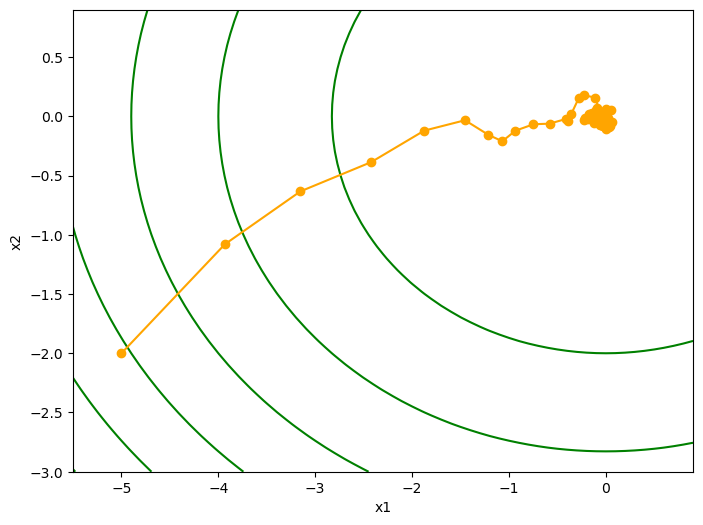

In [127]:
# 多项式衰减

def sgd(eta, f_grad, x1, x2):
    results = [[x1, x2]]
    eta = (1 + 0.1 * torch.arange(50)) ** (-0.5) * 0.1
    for epoch in range(50):
        g1, g2 = f_grad(x1, x2)
        g1 += torch.normal(0, 1, (1,)).item()
        g2 += torch.normal(0, 1, (1,)).item()
        x1 = x1 - eta[epoch] * g1
        x2 = x2 - eta[epoch] * g2
        results.append([x1, x2])
    print(f'epoch:{epoch}\tx1:{x1:.5f},x2:{x2:.5f}')
    return torch.tensor(results, dtype=float)

results = sgd(0.1, f_grad, -5, -2)
GradientPlot_2d([-5.5, 1.0], [-3.0, 1.0], f, results)


### 凸目标的收敛性分析

### 随机梯度和有限样本

有替换的采样一些样本恰好一次的概率是0.37，导致较之于无替换采样方差增加，数据效率降低，故实践中采用无替换采样

## 7.5 小批量随机梯度下降
### 向量化和缓存

矩阵-矩阵乘法为例，如$\mathbf {A=BC}$

- 逐元素计算：$\mathbf A_{ij}=\mathbf B_{i:,}C_{:,j}^\top$，通过点积逐元素计算
- 矩阵向量乘法：$\mathbf A_{:,j}=\mathbf BC_{:,j}^\top$，可以一次计算一列，也可以一次计算一行
- 直接矩阵乘法：$\mathbf{A=BC}$
- 分区计算：将$\mathbf B和\mathbf C$分成较小的区块矩阵，然后一次计算A的一个区块。

In [135]:
A = torch.zeros(256, 256)
B = torch.randn(256, 256)
C = torch.randn(256, 256)

import time
# 逐元素计算时，每次计算一个元素A_ij，都需要将一行和一列向量复制到CPU中。

start = time.perf_counter()
for i in range(256):
    for j in range(256):
        A[i, j] = torch.dot(B[i,:], C[:, j])
end = time.perf_counter()

print(f"逐元素计算耗时: {end - start:.6f} 秒")

# 向量矩阵计算时，在遍历B的同时，将列向量C_j保留到CPU缓存中。将内存带宽需求减半，相应地提高了访问速度
start = time.perf_counter()
for j in range(256):
        A[:, j] = torch.mv(B, C[:, j])
end = time.perf_counter()
print(f"向量矩阵计算耗时: {end - start:.6f} 秒")

# 一次性计算A=BC
start = time.perf_counter()
A = torch.mm(B, C)
end = time.perf_counter()
print(f"矩阵乘法计算耗时: {end - start:.6f} 秒")

逐元素计算耗时: 0.523392 秒
向量矩阵计算耗时: 0.003613 秒
矩阵乘法计算耗时: 0.000192 秒


### 小批量

单个观测值更新参数时$\mathbf w\leftarrow\mathbf w-\eta_t\mathbf g_t$，消耗巨大，其中
$$
\mathbf g_t = \partial_\mathbf wf(\mathbf x_t, \mathbf w)
$$

将其应用于一个小批量观测值来提高此操作的计算效率，将$\mathbf g_t$替换为一个小批量而不是单个观测值

$$
\mathbf g_t = \partial_\mathbf w\frac{1}{|\mathcal B_t|}\sum_{i\in\mathbf\beta t}f(\mathbf x_i, \mathbf w)
$$

$\mathbf x_t,\mathcal B_t$的所有元素随机采样于训练集，因此期望不变，另一方面，小批量方差较之于单样本降低了$\sqrt b$。

In [136]:
start = time.perf_counter()
for j in range(0, 256, 64):
    A[:, j:j+64] = torch.mm(B, C[:, j:j+64])
end = time.perf_counter()

print(f"小批量矩阵乘法计算耗时: {end - start:.6f} 秒")

小批量矩阵乘法计算耗时: 0.006400 秒


### SGD实现

数据预处理，将数据进行归一化到均值为0，方差为1。

In [3]:
import sys
# sys.path.append('/home/kazundo/WorkSpace/Methods/bioinfo-dl-tutorial/src')
sys.path.append('/xjy/Project1/my_DeepLearnTest/bioinfo-dl-tutorial-main/src')

import torch
from torch import nn

from data.loaders import load_bulk_drug_response
from utils.DL import DataIter, TryGpu, train_class_model
from utils.Plot import LossAndAccPlot
from modules.ClassModels import MLP
from sklearn.model_selection import train_test_split

drug_mat = load_bulk_drug_response()
features = torch.tensor(drug_mat.data.values, device=TryGpu()).float()
labels = torch.tensor(drug_mat.target, device=TryGpu())

features = (features - features.mean(dim=0))/ features.std(dim=0)
X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.3)

loaders.py load successfully!


epoch:1
train loss:0.693192	train acc:0.49632
test  loss:0.693255	test  acc:0.48286
epoch:2
train loss:0.693188	train acc:0.49632
test  loss:0.693247	test  acc:0.48286
epoch:3
train loss:0.693184	train acc:0.49632
test  loss:0.693239	test  acc:0.48286
epoch:4
train loss:0.693180	train acc:0.49632
test  loss:0.693231	test  acc:0.48286
epoch:5
train loss:0.693176	train acc:0.49632
test  loss:0.693224	test  acc:0.48286
epoch:6
train loss:0.693172	train acc:0.49632
test  loss:0.693216	test  acc:0.48286
epoch:7
train loss:0.693168	train acc:0.49632
test  loss:0.693208	test  acc:0.48286
epoch:8
train loss:0.693164	train acc:0.49632
test  loss:0.693201	test  acc:0.48286
epoch:9
train loss:0.693160	train acc:0.49632
test  loss:0.693193	test  acc:0.48286
epoch:10
train loss:0.693156	train acc:0.49632
test  loss:0.693186	test  acc:0.48286
epoch:11
train loss:0.693152	train acc:0.49632
test  loss:0.693179	test  acc:0.48286
epoch:12
train loss:0.693149	train acc:0.49632
test  loss:0.693172	test  a

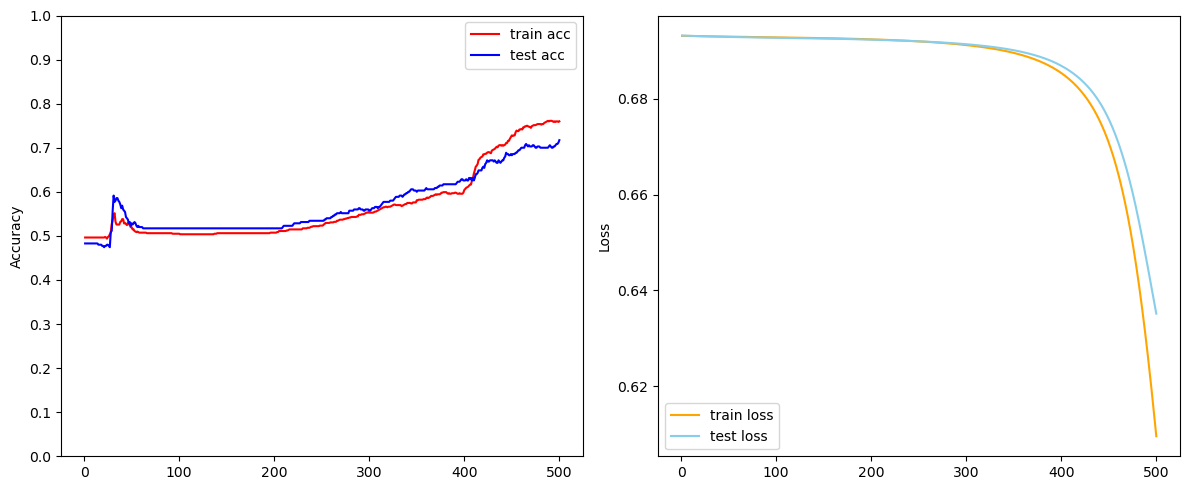

In [ ]:
# 全样本， 即梯度下降GD
batch_size = len(features)
dropout = 0
lr = 3e-2
epochs = 500
net = MLP(features.shape[1], [512, 256, 64], 2, dropout)
net.to(device=TryGpu())
for param in net.parameters():
    nn.init.normal_(param, 0, 0.01)
loss = nn.CrossEntropyLoss()
trainer = torch.optim.SGD(net.parameters(), lr=lr, weight_decay=0)

train_iter, test_iter = DataIter(batch_size, X_train, y_train), DataIter(batch_size, X_test, y_test)
net_, train_loss, test_loss, train_acc, test_acc = train_class_model(net, train_iter, test_iter, loss, epochs, trainer)
LossAndAccPlot(epochs, train_loss, test_loss, train_acc, test_acc)

epoch:1
train loss:0.693205	train acc:0.49510
test  loss:0.693373	test  acc:0.47429
epoch:2
train loss:0.693201	train acc:0.49510
test  loss:0.693364	test  acc:0.47429
epoch:3
train loss:0.693197	train acc:0.49265
test  loss:0.693355	test  acc:0.47429
epoch:4
train loss:0.693192	train acc:0.49510
test  loss:0.693346	test  acc:0.47143
epoch:5
train loss:0.693188	train acc:0.49632
test  loss:0.693337	test  acc:0.46857
epoch:6
train loss:0.693184	train acc:0.49020
test  loss:0.693329	test  acc:0.46286
epoch:7
train loss:0.693180	train acc:0.48529
test  loss:0.693321	test  acc:0.46000
epoch:8
train loss:0.693176	train acc:0.48529
test  loss:0.693313	test  acc:0.45714
epoch:9
train loss:0.693172	train acc:0.49142
test  loss:0.693305	test  acc:0.44857
epoch:10
train loss:0.693168	train acc:0.49020
test  loss:0.693297	test  acc:0.44286
epoch:11
train loss:0.693164	train acc:0.47794
test  loss:0.693290	test  acc:0.44571
epoch:12
train loss:0.693160	train acc:0.47794
test  loss:0.693282	test  a

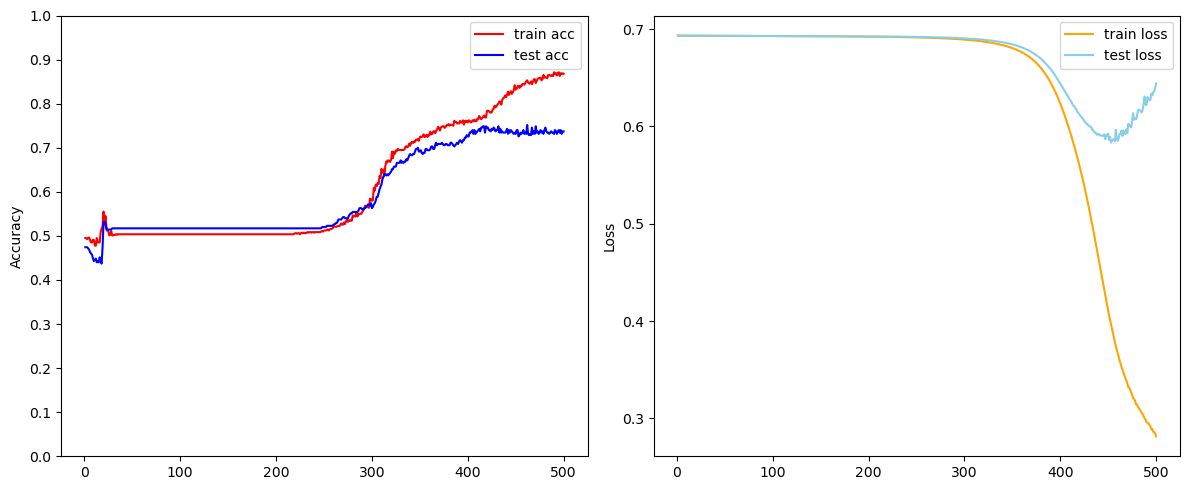

In [64]:
# 单样本，即随机梯度下降SGD
batch_size = 1
dropout = 0
lr = 5e-5
epochs = 500
net = MLP(features.shape[1], [512, 256, 64], 2, dropout)
net.to(device=TryGpu())
for param in net.parameters():
    nn.init.normal_(param, 0, 0.01)
loss = nn.CrossEntropyLoss()
trainer = torch.optim.SGD(net.parameters(), lr=lr, weight_decay=0)

train_iter, test_iter = DataIter(batch_size, X_train, y_train), DataIter(batch_size, X_test, y_test)
net_, train_loss, test_loss, train_acc, test_acc = train_class_model(net, train_iter, test_iter, loss, epochs, trainer)
LossAndAccPlot(epochs, train_loss, test_loss, train_acc, test_acc)

epoch:1
train loss:0.693335	train acc:0.49632
test  loss:0.693709	test  acc:0.48286
epoch:2
train loss:0.693326	train acc:0.49632
test  loss:0.693698	test  acc:0.48286
epoch:3
train loss:0.693318	train acc:0.49632
test  loss:0.693684	test  acc:0.48286
epoch:4
train loss:0.693313	train acc:0.49632
test  loss:0.693671	test  acc:0.48286
epoch:5
train loss:0.693305	train acc:0.49632
test  loss:0.693662	test  acc:0.48286
epoch:6
train loss:0.693298	train acc:0.49632
test  loss:0.693651	test  acc:0.48286
epoch:7
train loss:0.693303	train acc:0.49632
test  loss:0.693636	test  acc:0.48286
epoch:8
train loss:0.693296	train acc:0.49632
test  loss:0.693626	test  acc:0.48286
epoch:9
train loss:0.693281	train acc:0.49632
test  loss:0.693610	test  acc:0.48286
epoch:10
train loss:0.693272	train acc:0.49632
test  loss:0.693599	test  acc:0.48286
epoch:11
train loss:0.693267	train acc:0.49632
test  loss:0.693586	test  acc:0.48286
epoch:12
train loss:0.693262	train acc:0.49632
test  loss:0.693573	test  a

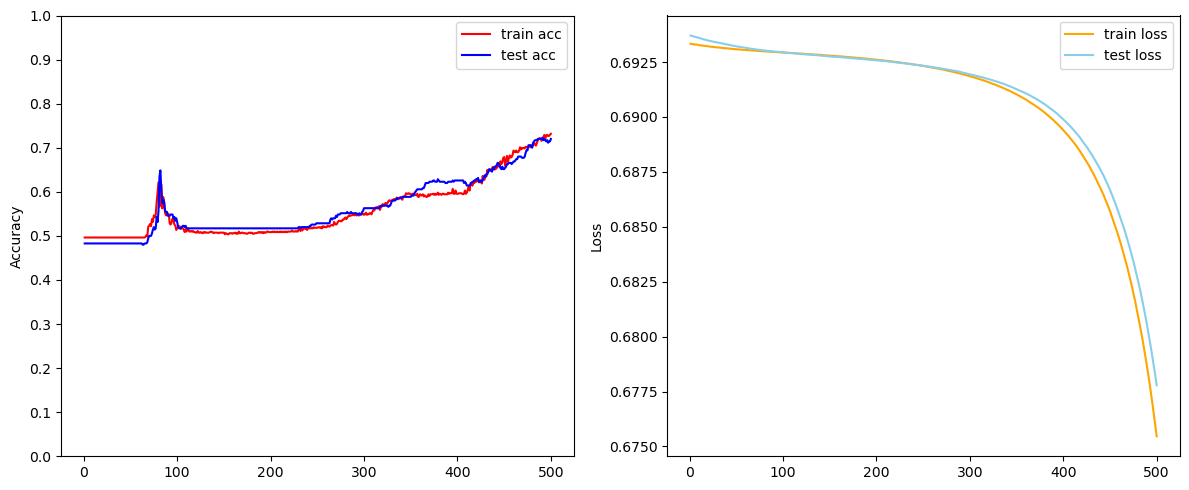

In [ ]:
# 小批量随机梯度下降batch gradiant descent
batch_size = 32
dropout = 0
lr = 5e-3
epochs = 500
net = MLP(features.shape[1], [512, 256, 64], 2, dropout)
net.to(device=TryGpu())
for param in net.parameters():
    nn.init.normal_(param, 0, 0.01)
loss = nn.CrossEntropyLoss()
trainer = torch.optim.SGD(net.parameters(), lr=lr, weight_decay=0)

train_iter, test_iter = DataIter(batch_size, X_train, y_train), DataIter(batch_size, X_test, y_test)
net_, train_loss, test_loss, train_acc, test_acc = train_class_model(net, train_iter, test_iter, loss, epochs, trainer)
LossAndAccPlot(epochs, train_loss, test_loss, train_acc, test_acc)

## 7.6 动量法

### 基础

#### 泄露平均值

小批量随机梯度下降作为加速计算的手段，平均梯度减小了方差。计算为
$$
\mathbf{g}_{t,t-1}=\partial_\mathbf w\frac{1}{|\mathcal B_t|}\sum_{i\in\mathcal B_t}f(\mathbf x_i, \mathbf w_{t-1})=\frac{1}{\mathcal B_t}\sum_{i\in\mathcal B_t}\mathbf h_{i, t-1}
$$
使用$\mathbf h_{i, t-1}=\partial_\mathbf{w}f(\mathbf x_i, \mathbf w_{t-1})作为沿样本i的随机梯度下降，使用时间$t-1$时更新的权重$t-1$。用泄露平均值（leaky average）取代梯度计算
$$
\mathbf v_t=\beta \mathbf v_{t-1}+\mathbf g_{t, t-1} 
$$
其中$\beta\in(0, 1)$。这有效地将瞬时梯度替换为多个“过去”梯度的平均值。$\mathbf v$称为动量（momentum），累积了过去的梯度。将$\mathbf v_t$递归拓展到
$$
\mathbf v_t=\beta^2\mathbf v_{t-2}+\beta\mathbf g_{t-1, t-2}+\mathbf g_{t, t-1}=...,=\sum_{\tau=0}^{t-1}\beta^\tau\mathbf g_{t-\tau, t-\tau-1}
$$

其中较大的β相当于长期平均值，较小的β相对于梯度法只是略有修正。新的梯度替换不再指向特定实例下降最陡的方向，而是过去梯度的加权平均值的方向。

#### 条件不佳的问题



In [4]:
import matplotlib.pyplot as plt 

def GradientPlot_2d(x1_range, x2_range, f, results):
    
    plt.figure(figsize=(8,6))
    x1, x2 = torch.meshgrid(torch.arange(x1_range[0], x1_range[1], 0.1), 
                            torch.arange(x2_range[0], x2_range[1], 0.1), indexing='ij' )
    plt.contour(x1, x2, f(x1, x2), colors='green')
    plt.plot(*zip(*results), '-o', color='orange') # 内层*号将列表打开，作为输入参数，zip函数按列重组，外层*号打开为两列输入
    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.show()

epoch:49	x1:-0.07733,x2:-0.00000


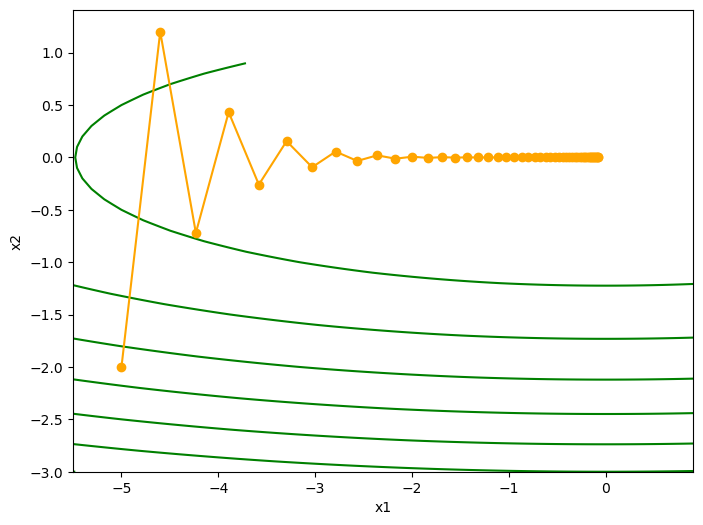

In [5]:
eta = 0.4
def f_2d(x1, x2):
    return 0.1 * x1 ** 2 + 2 * x2 **2

def f_grad_2d(x1, x2):
    return 0.2 * x1, 4 * x2

def sgd(eta, f_grad, x1, x2):
    results = [[x1, x2]]

    for epoch in range(50):
        g1, g2 = f_grad(x1, x2)
        x1 = x1 - eta * g1
        x2 = x2 - eta * g2
        results.append([x1, x2])
    print(f'epoch:{epoch}\tx1:{x1:.5f},x2:{x2:.5f}')
    return torch.tensor(results, dtype=float)

results = sgd(0.4, f_grad_2d, -5, -2)
GradientPlot_2d([-5.5, 1.0], [-3.0, 1.0], f_2d, results)

x2方向的梯度比x1方向大得多，变化也快的多。若学习率较小，则x1收敛缓慢，若学习率较大，则x2方向发散

epoch:49	x1:-0.00838,x2:-40497832.47953


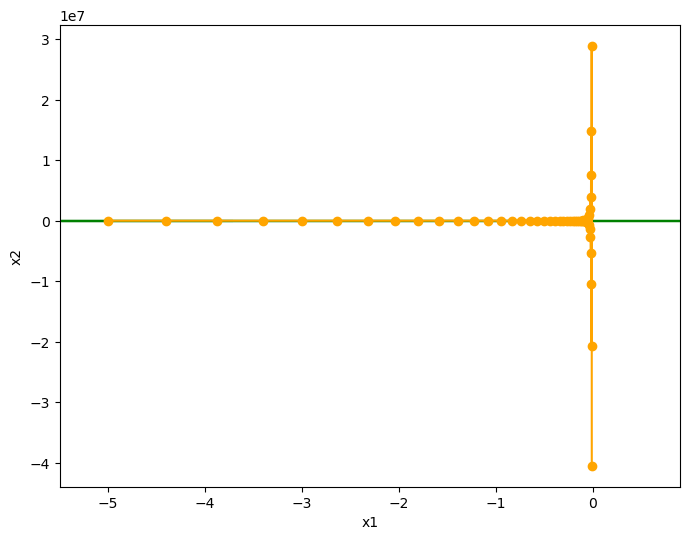

In [73]:
results = sgd(0.6, f_grad_2d, -5, -2)
GradientPlot_2d([-5.5, 1.0], [-3.0, 1.0], f_2d, results)

#### 动量法

动量法（momentum），直觉上计算过去的平均梯度会比较好。在x1方向上，这将聚合非常对齐的梯度以增加覆盖的距离。在震荡的x2方向上，互相抵消了对方的震荡。以下式更新：
$$
\mathbf v_t\leftarrow\beta\mathbf v_{t-1}+\mathbf g_{t, t-1}\\
\mathbf x_t\leftarrow\mathbf x_{t-1}-\eta_t\mathbf v_t 
$$


epoch:49	x1:0.00000,x2:-0.00000


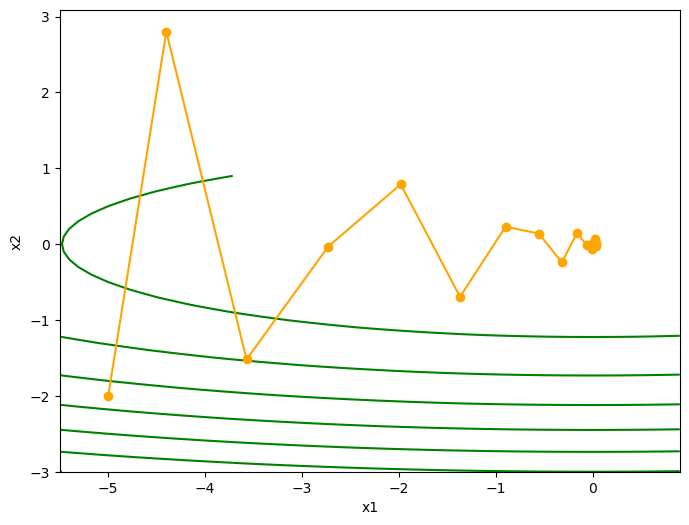

In [76]:
def sgd_momentum(eta, beta, f_grad, x1, x2):
    results = [[x1, x2]]
    v1, v2 = 0, 0
    for epoch in range(50):
        g1, g2 = f_grad(x1, x2)
        v1 = beta * v1 + g1
        v2 = beta * v2 + g2
        x1 = x1 - eta * v1
        x2 = x2 - eta * v2
        results.append([x1, x2])
    print(f'epoch:{epoch}\tx1:{x1:.5f},x2:{x2:.5f}')
    return torch.tensor(results, dtype=float)

results = sgd_momentum(0.6, 0.5, f_grad_2d, -5, -2)
GradientPlot_2d([-5.5, 1.0], [-3.0, 1.0], f_2d, results)

epoch:49	x1:-0.00044,x2:-0.00195


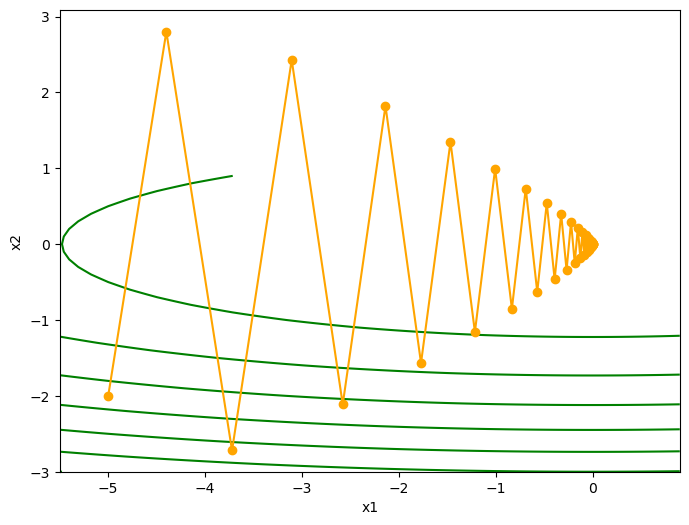

In [77]:
results = sgd_momentum(0.6, 0.25, f_grad_2d, -5, -2)
GradientPlot_2d([-5.5, 1.0], [-3.0, 1.0], f_2d, results)

#### 有效样本权重

极限条件下，$\sum_{\tau=0}^\infty\beta^\tau=\frac{1}{1-\beta}$，即选取步长为$\frac{\eta}{1-\beta}$。

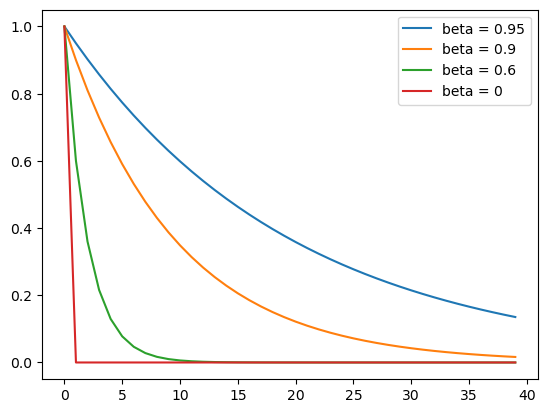

In [79]:
x = torch.arange(40).detach().numpy()
for beta in [0.95, 0.9, 0.6, 0]:
    plt.plot(x, beta ** x, label=f'beta = {beta}')
plt.legend()

### 实际实验

epoch:1
train loss:0.693145	train acc:0.50368
test  loss:0.693045	test  acc:0.51714
epoch:2
train loss:0.693140	train acc:0.50368
test  loss:0.693042	test  acc:0.51714
epoch:3
train loss:0.693140	train acc:0.50368
test  loss:0.693037	test  acc:0.51714
epoch:4
train loss:0.693137	train acc:0.50368
test  loss:0.693037	test  acc:0.51714
epoch:5
train loss:0.693149	train acc:0.50368
test  loss:0.693028	test  acc:0.51714
epoch:6
train loss:0.693132	train acc:0.50368
test  loss:0.693032	test  acc:0.51714
epoch:7
train loss:0.693134	train acc:0.50368
test  loss:0.693035	test  acc:0.51714
epoch:8
train loss:0.693130	train acc:0.50368
test  loss:0.693033	test  acc:0.51714
epoch:9
train loss:0.693130	train acc:0.50368
test  loss:0.693035	test  acc:0.51714
epoch:10
train loss:0.693130	train acc:0.50368
test  loss:0.693038	test  acc:0.51714
epoch:11
train loss:0.693131	train acc:0.50368
test  loss:0.693028	test  acc:0.51714
epoch:12
train loss:0.693127	train acc:0.50368
test  loss:0.693029	test  a

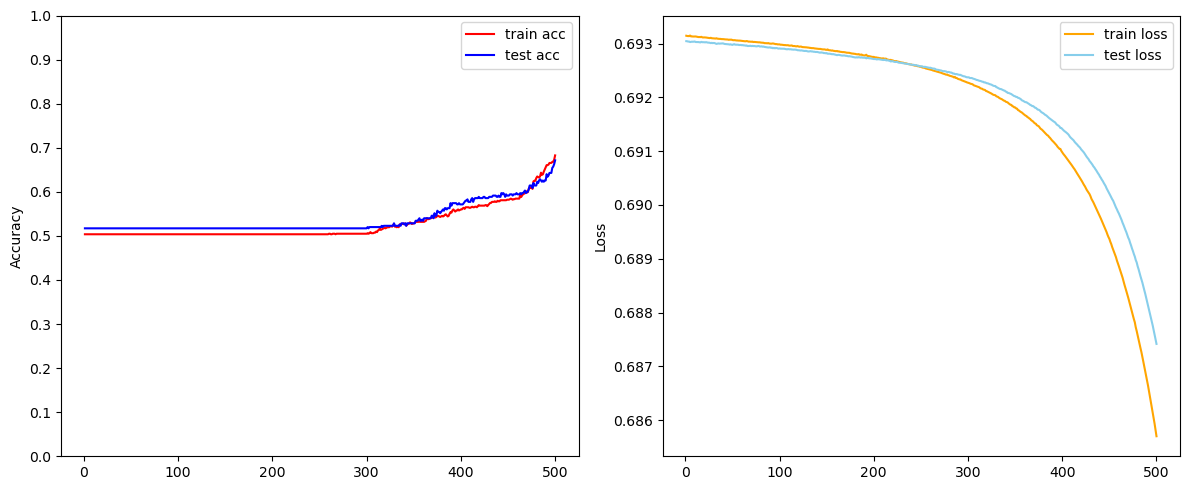

In [90]:
# 小批量随机梯度下降batch gradiant descent
batch_size = 32
dropout = 0
lr = 1e-4
epochs = 500
net = MLP(features.shape[1], [512, 256, 64], 2, dropout)
net.to(device=TryGpu())
for param in net.parameters():
    nn.init.normal_(param, 0, 0.01)
loss = nn.CrossEntropyLoss()
trainer = torch.optim.SGD(net.parameters(), lr=lr, momentum=0.9)

train_iter, test_iter = DataIter(batch_size, X_train, y_train), DataIter(batch_size, X_test, y_test)
net_, train_loss, test_loss, train_acc, test_acc = train_class_model(net, train_iter, test_iter, loss, epochs, trainer)
LossAndAccPlot(epochs, train_loss, test_loss, train_acc, test_acc)

### 理论分析

#### 二次凸函数

函数
$$
h(\mathbf x)=\frac12\mathbf{x^\top Qx+x^\top c}+b
$$

对于正定矩阵$\mathbf Q\gt 0$，即对于具有正特征值的矩阵，最小化为$\mathbf{x^*=-Q^{-1}c}$。h重写为
$$
h(\mathbf x)=\frac12\mathbf{(x-Q^{-1}c)^\top Q(x-Q^{-1}c)+b-\frac12\mathbf{c^\top Q^{-1}c}}
$$
结论是带有和带有不凸二次函数动量的梯度下降，可以分解为朝二次矩阵特征向量方向坐标顺序的优化


## 7.7 AdaGrad算法

### 稀疏特征和学习率

为获得良好的准确性，希望在训练的过程中逐渐降低学习率，速度通常为$\mathcal O(t^{-\frac12})$或更低。只有在这些稀疏特征出现时，与其相关的参数才会得到有意义的更新。学习率下降会导致常见特征的参数迅速地收敛到最佳值，稀疏特征缺乏足够的观测确定最佳值。即学习率要么对于常见特征而言降低太慢，要么对于稀疏特征而言降低太快。

一个解决办法就是记录看到特定特征的次数，用其调整学习率。使用$\eta_i=\frac{\eta_0}{\sqrt{s(i, t)+c}}$的学习率。$s(i, t)$记下了截至t时观察到功能i的次数。

AdaGrad算法通过粗略的计数器$s(i,t)$替换为先前观察到所得梯度的平方之和。使用$s(i, t+1)=s(i, t)+(\partial_i f(\mathbf x))^2$来调整学习率。好处是：
- 不需要决定梯度何时算足够大
- 随梯度的大小自动变化
通常对应于较大梯度的坐标会显著缩小，其他梯度较小的坐标会得到更平滑的处理。

### 算法

使用变量$\mathbf s_t$累积过去的梯度方差
$$
\begin{aligned}
\mathbf g_t &= \partial_\mathbf wl(y_t,f(\mathbf x_t,w))\\
\mathbf s_t &= s_{t-1}+\mathbf g_t^2\\
\mathbf w_t &= w_{t-1}-\frac{\eta}{\sqrt{\mathbf s_t+\epsilon}}\mathbf g_t
\end{aligned}
$$
累加平方梯度意味着$\mathbf s_t$以线性速率增长。产生了一个学习率$\mathcal O(t^{-\frac12})$


epoch:19	x1:-2.38256,x2:-0.15859


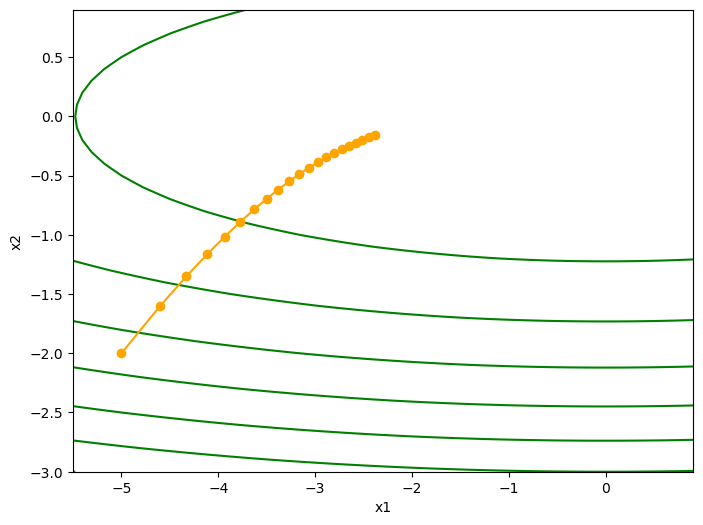

In [102]:
import numpy as np
def adagrad_2d(eta, epsilon, f_grad, x1, x2):
    results = [[x1, x2]]
    s1, s2 = 0, 0
    for epoch in range(20):
        g1, g2 = f_grad(x1, x2)
        s1 += g1 ** 2
        s2 += g2 ** 2
        x1 -= eta / np.sqrt(s1 + epsilon) * g1
        x2 -= eta / np.sqrt(s2 + epsilon) * g2
        results.append([x1, x2])
    print(f'epoch:{epoch}\tx1:{x1:.5f},x2:{x2:.5f}')
    return torch.tensor(results, dtype=float)

results = adagrad_2d(0.4, 1e-6, f_grad_2d, -5, -2)
GradientPlot_2d([-5.5, 1.0], [-3.0, 1.0], f_2d, results)

epoch:19	x1:-0.00230,x2:-0.00000


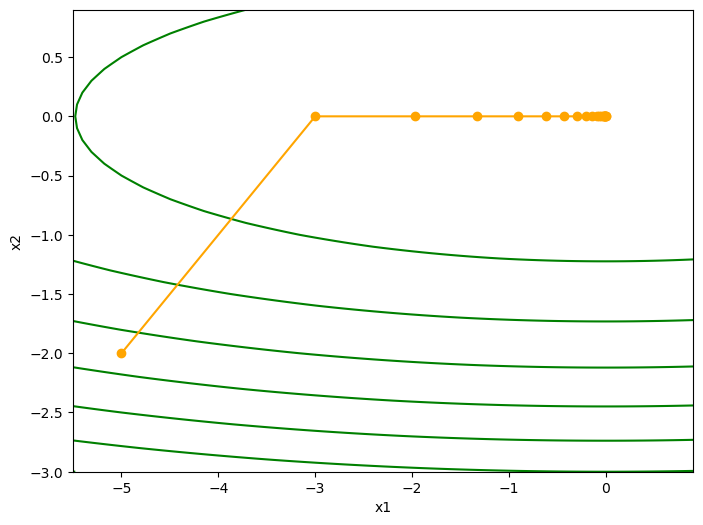

In [103]:
# 学习率提高到2
results = adagrad_2d(2, 1e-6, f_grad_2d, -5, -2)
GradientPlot_2d([-5.5, 1.0], [-3.0, 1.0], f_2d, results)

epoch:1
train loss:0.692918	train acc:0.52206
test  loss:0.693045	test  acc:0.48571
epoch:2
train loss:0.692786	train acc:0.52083
test  loss:0.692993	test  acc:0.49429
epoch:3
train loss:0.692818	train acc:0.53431
test  loss:0.692924	test  acc:0.50857
epoch:4
train loss:0.692862	train acc:0.52328
test  loss:0.692872	test  acc:0.52000
epoch:5
train loss:0.692788	train acc:0.53922
test  loss:0.692827	test  acc:0.54286
epoch:6
train loss:0.692629	train acc:0.52574
test  loss:0.692783	test  acc:0.53714
epoch:7
train loss:0.692730	train acc:0.52206
test  loss:0.692723	test  acc:0.53429
epoch:8
train loss:0.692667	train acc:0.52941
test  loss:0.692670	test  acc:0.53429
epoch:9
train loss:0.692188	train acc:0.56373
test  loss:0.692620	test  acc:0.53429
epoch:10
train loss:0.692417	train acc:0.55025
test  loss:0.692564	test  acc:0.54286
epoch:11
train loss:0.692310	train acc:0.54902
test  loss:0.692524	test  acc:0.54857
epoch:12
train loss:0.692106	train acc:0.56740
test  loss:0.692477	test  a

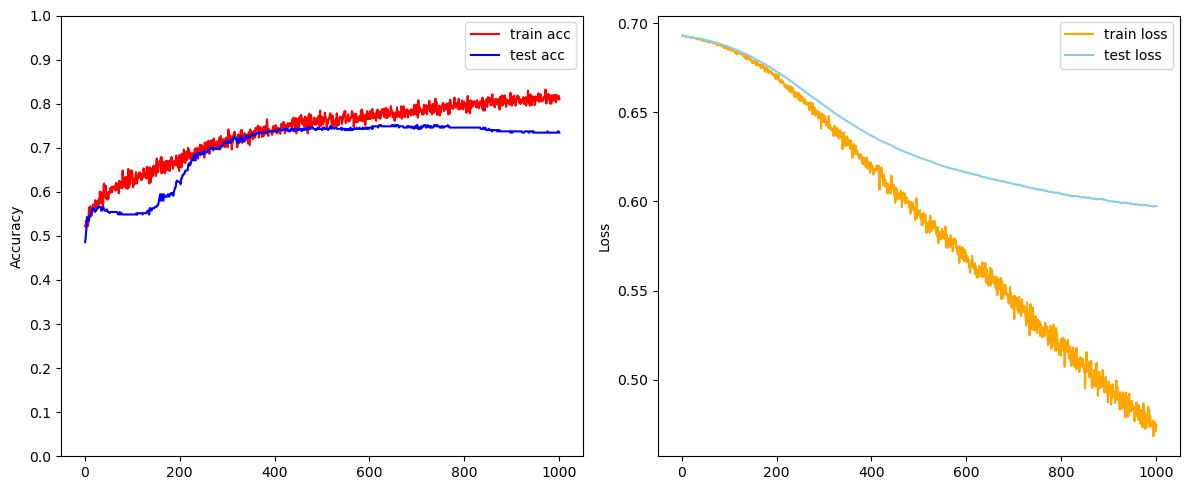

In [116]:
batch_size = 32
dropout = 0.5
lr = 3e-5
epochs = 1000
net = MLP(features.shape[1], [512, 256, 64], 2, dropout)
net.to(device=TryGpu())
for param in net.parameters():
    nn.init.normal_(param, 0, 0.01)
loss = nn.CrossEntropyLoss()
trainer = torch.optim.Adagrad(net.parameters(), lr=lr, weight_decay=1e-3)

train_iter, test_iter = DataIter(batch_size, X_train, y_train), DataIter(batch_size, X_test, y_test)
net_, train_loss, test_loss, train_acc, test_acc = train_class_model(net, train_iter, test_iter, loss, epochs, trainer)
LossAndAccPlot(epochs, train_loss, test_loss, train_acc, test_acc)

## 7.8 RMSProp算法

AdaGrad算法的学习率按照预定时间表$\mathcal O(t)$显著降低。虽然通常适用于凸问题，但对于非凸问题可能并不理想。

问题在于算法将梯度$\mathrm g_t$的平方类加成状态矢量$\mathrm s_t=\mathrm s_{t+1}+\mathrm g_t^2$，缺乏规范化导致$\mathrm s_t$持续增长，在算法收敛时呈线性递增。

一种解决办法是按动量法中的方式使用泄露平均值，即$\mathbf s_t\leftarrow\gamma\mathrm s_{t-1}+(1-\gamma)\mathrm g_t^2$，保持其他部分不变就产生了RMSProp算法

### 算法
$$
\begin{aligned}
\mathbf s_t &\leftarrow\gamma\mathrm s_{t-1}+(1-\gamma)\mathrm g_t^2, \\
\mathbf w_t &\leftarrow w_{t-1}-\frac{\eta}{\sqrt{\mathbf s_t+\epsilon}}\mathbf g_t
\end{aligned}
$$
常数$\epsilon$通常设置为1e-6，确保不会因除以0或步长太大受影响。$\mathbf s_t$更新为
$$
\begin{aligned}
\mathbf s_t&=(1-\gamma)\mathbf g_t^2+\gamma\mathbf s_{t-1}
&=(1-\lambda)(\mathbf g_t^2+\gamma\mathbf g^2_{t-1}+\gamma^2\mathbf g^2_{t-2}+...) 
\end{aligned}
$$

因此，权重总和标准化为1，且观测值的半衰期为$\gamma^{-1}$

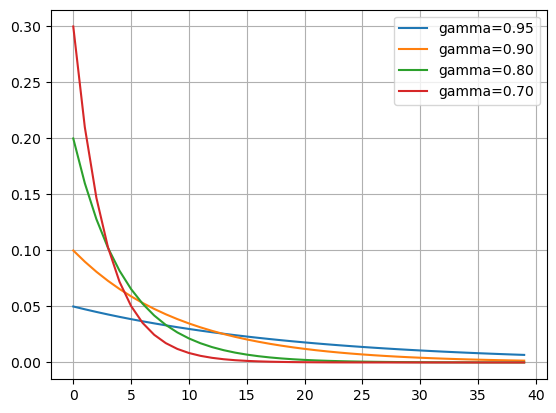

In [120]:
gammas = [0.95, 0.9, 0.8, 0.7]
for gamma in gammas:
    x = torch.arange(40).detach().numpy()
    plt.plot(x, (1-gamma)* gamma ** x, label=f'gamma={gamma:.2f}')
plt.grid()
plt.legend()
plt.show()

### 实际实验

epoch:19	x1:-0.01060,x2:0.00000


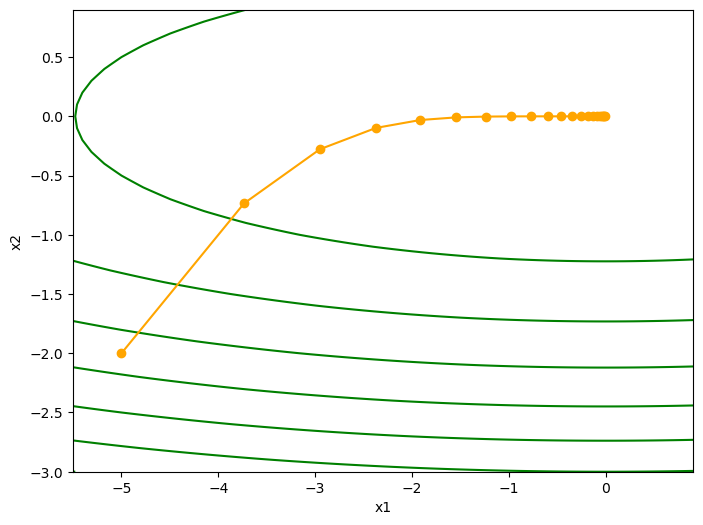

In [122]:
def rmsprop_2d(eta, gamma, epsilon, f_grad, x1, x2):
    results = [[x1, x2]]
    s1, s2 = 0, 0
    for epoch in range(20):
        g1, g2 = f_grad(x1, x2)
        s1 = s1 * gamma + (1-gamma) * g1 ** 2
        s2 = s2 * gamma + (1-gamma) * g2 ** 2
        x1 -= eta / np.sqrt(s1 + epsilon) * g1
        x2 -= eta / np.sqrt(s2 + epsilon) * g2
        results.append([x1, x2])
    print(f'epoch:{epoch}\tx1:{x1:.5f},x2:{x2:.5f}')
    return torch.tensor(results, dtype=float)

results = rmsprop_2d(0.4, 0.9, 1e-6, f_grad_2d, -5, -2)
GradientPlot_2d([-5.5, 1.0], [-3.0, 1.0], f_2d, results)

epoch:1
train loss:0.693091	train acc:0.51838
test  loss:0.693134	test  acc:0.51714
epoch:2
train loss:0.693394	train acc:0.48284
test  loss:0.693115	test  acc:0.51714
epoch:3
train loss:0.693133	train acc:0.49265
test  loss:0.693095	test  acc:0.52000
epoch:4
train loss:0.693266	train acc:0.49142
test  loss:0.693083	test  acc:0.52000
epoch:5
train loss:0.693138	train acc:0.50123
test  loss:0.693064	test  acc:0.52000
epoch:6
train loss:0.693039	train acc:0.50980
test  loss:0.693059	test  acc:0.52000
epoch:7
train loss:0.693107	train acc:0.48039
test  loss:0.693047	test  acc:0.52000
epoch:8
train loss:0.692942	train acc:0.52206
test  loss:0.693039	test  acc:0.52000
epoch:9
train loss:0.692970	train acc:0.51961
test  loss:0.693031	test  acc:0.52000
epoch:10
train loss:0.693012	train acc:0.51103
test  loss:0.693021	test  acc:0.52000
epoch:11
train loss:0.692917	train acc:0.52328
test  loss:0.693014	test  acc:0.52000
epoch:12
train loss:0.692868	train acc:0.54044
test  loss:0.692997	test  a

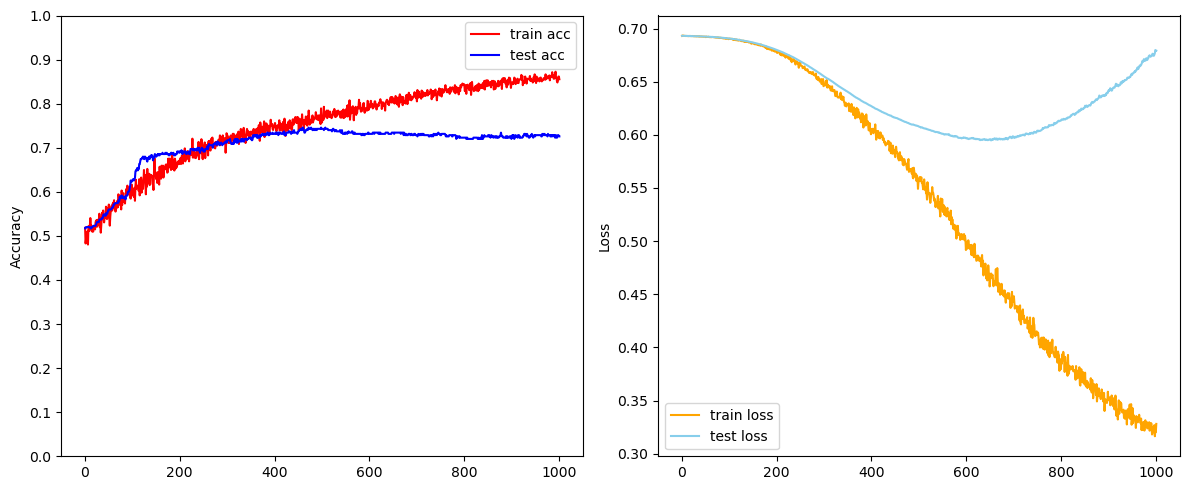

In [129]:
batch_size = 32
dropout = 0.5
lr = 1e-6
epochs = 1000
net = MLP(features.shape[1], [512, 256, 64], 2, dropout)
net.to(device=TryGpu())
for param in net.parameters():
    nn.init.normal_(param, 0, 0.01)
loss = nn.CrossEntropyLoss()
trainer = torch.optim.RMSprop(net.parameters(), alpha=0.9, lr=lr, weight_decay=1e-3)

train_iter, test_iter = DataIter(batch_size, X_train, y_train), DataIter(batch_size, X_test, y_test)
net_, train_loss, test_loss, train_acc, test_acc = train_class_model(net, train_iter, test_iter, loss, epochs, trainer)
LossAndAccPlot(epochs, train_loss, test_loss, train_acc, test_acc)

## 7.9 Adadelta算法

Adadelta是AdaGrad的另一种变体， 减少了学习率适应坐标的数量。

### Adadelta算法

Adadelta适应两个状态变量，$\mathbf s_t$存储梯度二阶导数的泄露平均值，$\Delta\mathbf x_t$用于存储模型本身中参数变化二阶导数的泄露平均值。更新为:
$$
\begin{aligned}
\mathbf s_t &=\rho\mathbf s_{t-1}+(1-\rho)\mathbf g_t^2\\
\mathbf g'_t &=\frac{\sqrt{\mathbf\Delta x_{t-1}+\epsilon}}{\sqrt{\mathbf s_t+\epsilon}}\odot\mathbf g_t\\
\mathbf \Delta\mathbf x_t &=\rho\Delta\mathbf x_{t-1}+(1-\rho)\mathbf g'^2 \\
\mathbf x_t &= \mathbf x_{t-1}-\mathbf g'_t
\end{aligned}
$$
$\Delta x_0$初始化为0

epoch:399	x1:-0.59714,x2:-0.00001


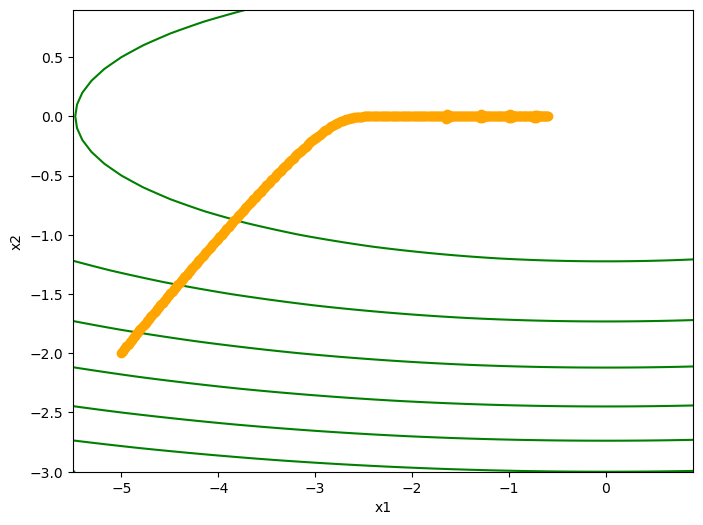

In [32]:
def adadelta_2d(rho, epsilon, f_grad, x1, x2):
    results = [[x1, x2]]
    s1, s2, x_delta1, x_delta2 = 0, 0, 0, 0
    for epoch in range(400):
        g1, g2 = f_grad(x1, x2)
        s1 = s1 * rho + (1-rho) * g1 ** 2
        s2 = s2 * rho + (1-rho) * g2 ** 2
        g1_ = np.sqrt(x_delta1 + epsilon) / np.sqrt(s1 + epsilon) * g1
        g2_ = np.sqrt(x_delta2 + epsilon) / np.sqrt(s2 + epsilon) * g2
        x1 -=  g1_
        x2 -=  g2_
        x_delta1 = x_delta1 * rho + (1-rho) * g1_ ** 2
        x_delta2 = x_delta1 * rho + (1-rho) * g2_ ** 2

        results.append([x1, x2])
    print(f'epoch:{epoch}\tx1:{x1:.5f},x2:{x2:.5f}')
    return torch.tensor(results, dtype=float)

results = adadelta_2d(0.9, 1e-5, f_grad_2d, -5, -2)
GradientPlot_2d([-5.5, 1.0], [-3.0, 1.0], f_2d, results)

epoch:1
train loss:0.692881	train acc:0.52574
test  loss:0.693275	test  acc:0.48571
epoch:2
train loss:0.693063	train acc:0.51593
test  loss:0.693275	test  acc:0.48571
epoch:3
train loss:0.692757	train acc:0.51593
test  loss:0.693274	test  acc:0.48571
epoch:4
train loss:0.693145	train acc:0.50735
test  loss:0.693275	test  acc:0.48571
epoch:5
train loss:0.692993	train acc:0.51593
test  loss:0.693276	test  acc:0.48571
epoch:6
train loss:0.693030	train acc:0.51103
test  loss:0.693276	test  acc:0.48571
epoch:7
train loss:0.692982	train acc:0.50980
test  loss:0.693276	test  acc:0.48571
epoch:8
train loss:0.692981	train acc:0.51961
test  loss:0.693278	test  acc:0.48571
epoch:9
train loss:0.692984	train acc:0.51471
test  loss:0.693278	test  acc:0.48571
epoch:10
train loss:0.693039	train acc:0.51961
test  loss:0.693276	test  acc:0.48571
epoch:11
train loss:0.692905	train acc:0.52574
test  loss:0.693276	test  acc:0.48571
epoch:12
train loss:0.693055	train acc:0.51103
test  loss:0.693273	test  a

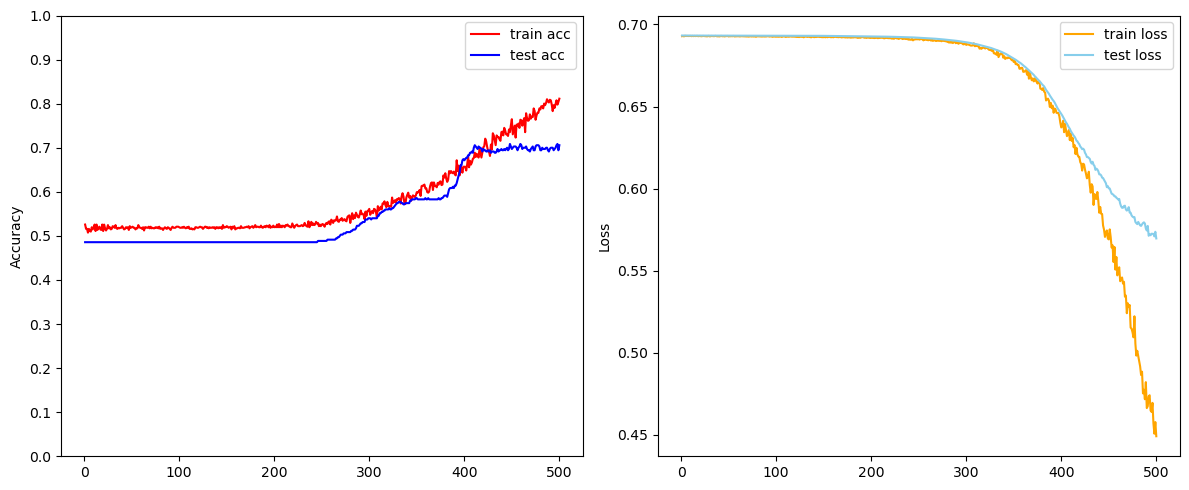

In [37]:
batch_size = 32
dropout = 0.5
lr = 3e-3
epochs = 500
net = MLP(features.shape[1], [512, 256, 64], 2, dropout)
net.to(device=TryGpu())
for param in net.parameters():
    nn.init.normal_(param, 0, 0.01)
loss = nn.CrossEntropyLoss()
trainer = torch.optim.Adadelta(net.parameters(), rho=0.9, lr=lr)

train_iter, test_iter = DataIter(batch_size, X_train, y_train), DataIter(batch_size, X_test, y_test)
net_, train_loss, test_loss, train_acc, test_acc = train_class_model(net, train_iter, test_iter, loss, epochs, trainer)
LossAndAccPlot(epochs, train_loss, test_loss, train_acc, test_acc)

## 7.10 Adam算法
回顾之前的算法：
- SGD：随机梯度下降在解决优化问题时比梯度下降更有效
- 小批量SGD：在一个小批量中适应更大的观测值集，可以通过向量化提供额外效率。这是高效的多机、多GPU和整体并行处理的关键
- 动量法：汇总过去梯度的历史以加速收敛
- AdaGrad：对每个坐标缩放来实现高效计算的预处理器
- RMSProp：提供学习率的调整来分离每个坐标的缩放

### 算法
Adam算法的关键组成部分之一是：使用指数加权移动平均值来估算梯度的动量和二次矩，使用状态变量
$$
\begin{aligned}
\mathbf v_t&\leftarrow\beta_1\mathbf v_{t-1}+(1-\beta_1)\mathbf g_t\\
\mathbf s_t&\leftarrow\beta_2\mathbf s_{t-1}+(1-\beta_2)\mathbf g_t^2
\end{aligned}
$$
$\beta_1、\beta_2$是非负加权参数，设置为$\beta_1=0.9,\beta_2=0.999$，即方差估计的移动要远远慢于动量估计的移动。
标准化状态变量由下式得到
$$
\mathbf{\hat v}_t=\frac{\mathbf v_t}{1-\beta_t}\mathrm{and\ }\mathbf{\hat s}_t=\frac{\mathbf s_t}{1-\beta_2^t}
$$

重新缩放梯度为
$$
\mathbf g'_t=\frac{\eta\hat{\mathbf v}}{\sqrt{\hat{\mathbf s}}+\epsilon}
$$
与RMSProp不同，更新使用动量$\hat{\mathbf v}_t$而不是梯度。更新为
$$
\mathbf x_t\leftarrow\mathbf x_{t-1}-\mathbf g'_t
$$


epoch:1
train loss:0.692970	train acc:0.51593
test  loss:0.693327	test  acc:0.48571
epoch:2
train loss:0.693063	train acc:0.51716
test  loss:0.693319	test  acc:0.48571
epoch:3
train loss:0.692977	train acc:0.52083
test  loss:0.693305	test  acc:0.48571
epoch:4
train loss:0.692938	train acc:0.52083
test  loss:0.693295	test  acc:0.48571
epoch:5
train loss:0.692969	train acc:0.51716
test  loss:0.693289	test  acc:0.48571
epoch:6
train loss:0.693032	train acc:0.51471
test  loss:0.693278	test  acc:0.48571
epoch:7
train loss:0.692983	train acc:0.51593
test  loss:0.693270	test  acc:0.48571
epoch:8
train loss:0.692943	train acc:0.52083
test  loss:0.693254	test  acc:0.48571
epoch:9
train loss:0.692901	train acc:0.52206
test  loss:0.693246	test  acc:0.48571
epoch:10
train loss:0.692873	train acc:0.51961
test  loss:0.693234	test  acc:0.48571
epoch:11
train loss:0.692854	train acc:0.51961
test  loss:0.693224	test  acc:0.48571
epoch:12
train loss:0.693025	train acc:0.51225
test  loss:0.693215	test  a

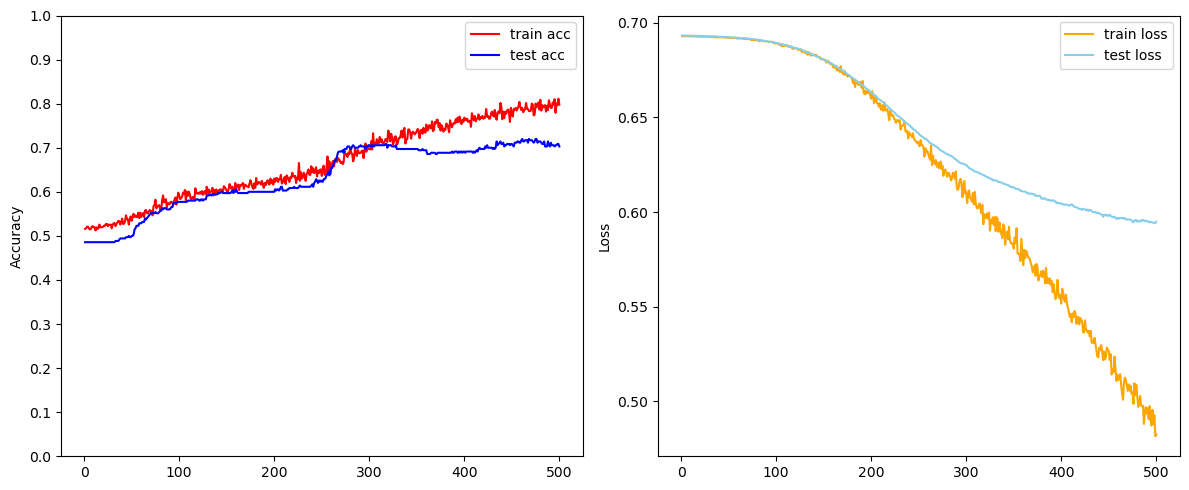

: 

In [ ]:
batch_size = 32
dropout = 0.5
lr = 1e-6
epochs = 500
net = MLP(features.shape[1], [512, 256, 64], 2, dropout)
net.to(device=TryGpu())
for param in net.parameters():
    nn.init.normal_(param, 0, 0.01)
loss = nn.CrossEntropyLoss()
trainer = torch.optim.Adam(net.parameters(), lr=lr)

train_iter, test_iter = DataIter(batch_size, X_train, y_train), DataIter(batch_size, X_test, y_test)
net_, train_loss, test_loss, train_acc, test_acc = train_class_model(net, train_iter, test_iter, loss, epochs, trainer)
LossAndAccPlot(epochs, train_loss, test_loss, train_acc, test_acc)

## 7.11 学习率调度器

前面研究了如何更新权重向量的优化算法而不是其更新速率。现在讨论实际算法：
- 首先，学习率的大小。若太大，优化会发散；若太小，训练就会需要过长时间，或者只能得到次优结果。
- 衰减速率也很重要。如果学习率持续过高，可能最终会在最小值附近弹跳而无法达到最优解。即希望速率衰减，但是比$\mathcal O(t^{-\frac12})$慢
- 初始化。涉及参数的设置方式，又关系到最初的演变方式。
- 许多优化变体执行周期性学习率的调整。梳理不同的调度策略对准确性的影响，并展示如何提高学习率调度器（learning rate scheduler）来有效管理。


